<p align="center">
  <img src="https://i0.wp.com/www.tiempodecine.co/web/wp-content/uploads/2015/11/Robert-De-Niro-in-Taxi-Driver-1976.jpg?resize=750%2C375&ssl=1" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Preparación de datos para Clustering de Zonas de NYC</span>
  </p>
</div>

# FASE 3: Data Preparation (CRISP-DM)

## Propósito de la Fase de Preparación de Datos

En esta tercera fase del proceso CRISP-DM, nos enfocamos en preparar los datos para aplicar **algoritmos de Clustering (No Supervisado)** con el objetivo de:

### **Problema de Negocio:**
- Algunas zonas tienen alta concentración de viajes en ciertas horas
- Otras zonas permanecen con poca actividad
- Dificulta la distribución eficiente de taxis y vehículos de alquiler

### **Objetivos:**
1. **Agrupar zonas** según volumen de viajes, hora pico y tipo de servicio
2. **Identificar áreas** con alta demanda o saturadas
3. **Optimizar** la asignación de flotas y planificación de estaciones

### **Tareas de esta Fase:**
- Feature Engineering para clustering
- Imputación de valores nulos
- Control de outliers
- Encoding de variables categóricas
- Normalización/Estandarización
- Creación de features agregadas por zona

# Carga de Librerías

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    
    # Librerías del sistema
    import sys, subprocess
    
    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    
    # Librerías de sistema de archivos
    import os as os  
    from os import path
    import pickle as pkl
    import joblib
    
    # Librerías de Machine Learning
    from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    
    print("Dependencias ya instaladas.")

except ImportError:
    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet scikit-learn
    %pip install --quiet pyarrow
    
    print("Instalación completada.")

Dependencias ya instaladas.


# Configuración de Visualización

In [2]:
# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Configuración de visualización completada.")

Configuración de visualización completada.


# 1. Carga de Datos Procesados

Cargamos los datasets que fueron preparados en las fases anteriores:

In [3]:
# Cargar datasets procesados de la fase anterior
print("Cargando datasets...")

# TAXIS (Yellow/Green) - Dataset equilibrado
taxis_df = pd.read_parquet('data/DataUnderstanding_taxis_sample.parquet')
print(f"✓ Taxis cargados: {len(taxis_df):,} registros")

# FHVHV (Uber/Lyft) - Muestra del 1%
fhvhv_df = pd.read_parquet('data/DataUnderstanding_fhvhv_sample.parquet')
print(f"✓ FHVHV cargados: {len(fhvhv_df):,} registros")

print("\n" + "="*60)
print("DATASETS CARGADOS EXITOSAMENTE")
print("="*60)

Cargando datasets...
✓ Taxis cargados: 96,410 registros
✓ FHVHV cargados: 565,248 registros

DATASETS CARGADOS EXITOSAMENTE


# 2. Exploración Inicial de Datos

In [4]:
# Información general del dataset de Taxis
print("=" * 60)
print("INFORMACIÓN DEL DATASET DE TAXIS")
print("=" * 60)
print(f"\nShape: {taxis_df.shape}")
print(f"\nColumnas: {list(taxis_df.columns)}")
print(f"\nTipos de datos:")
print(taxis_df.dtypes)
print(f"\nPrimeras filas:")
taxis_df.head()

INFORMACIÓN DEL DATASET DE TAXIS

Shape: (96410, 35)

Columnas: ['pickup_datetime', 'pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'time_band', 'dropoff_datetime', 'trip_duration_min', 'PULocationID', 'DOLocationID', 'VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'trip_type', 'fare_amount', 'total_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'cbd_congestion_fee', 'taxi_color', 'taxi_color_ini', 'is_color', 'dropoff_hour', 'pickup_band', 'dropoff_band', 'day_type']

Tipos de datos:
pickup_datetime          datetime64[us]
pickup_year                       int32
pickup_month                      int32
pickup_day                        int32
pickup_hour                       int32
pickup_day_of_week                int32
is_weekend                        int64
time_band                        object
dropoff_datetime         date

,pickup_datetime,pickup_year,pickup_month,pickup_day,pickup_hour,pickup_day_of_week,is_weekend,time_band,dropoff_datetime,trip_duration_min,PULocationID,DOLocationID,VendorID,passenger_count,trip_distance,RatecodeID,payment_type,store_and_fwd_flag,trip_type,fare_amount,total_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,cbd_congestion_fee,taxi_color,taxi_color_ini,is_color,dropoff_hour,pickup_band,dropoff_band,day_type
0,2025-07-27 14:39:54,2025,7,27,14,6,1,OP_day,2025-07-27 14:57:30,17.600,74,238,1,NaN,2.900,NaN,NaN,None,NaN,18.400,26.050,0.000,0.500,3.400,0.000,1.000,NaN,0.000,green,G,0,14,OP_day,OP_day,Fin de semana
1,2025-07-19 20:20:42,2025,7,19,20,5,1,OP_night,2025-07-19 21:14:26,53.730,230,61,6,NaN,9.380,NaN,NaN,None,NaN,2.900,45.130,0.000,0.500,0.000,0.000,0.300,NaN,0.000,green,G,0,21,OP_night,OP_night,Fin de semana
2,2025-07-06 17:33:49,2025,7,6,17,6,1,PM_Peak,2025-07-06 17:52:40,18.850,74,140,2,1.000,3.520,1.000,1.000,N,1.000,20.500,28.460,0.000,0.500,3.710,0.000,1.000,2.750,0.000,green,G,0,17,PM_Peak,PM_Peak,Fin de semana
3,2025-07-14 00:13:05,2025,7,14,0,0,0,Early_Morning,2025-07-14 00:19:33,6.470,238,48,2,2.000,2.010,1.000,1.000,N,NaN,10.700,19.740,1.000,0.500,3.290,0.000,1.000,2.500,0.750,yellow,Y,1,0,Early_Morning,Early_Morning,Laborable
4,2025-07-29 19:35:37,2025,7,29,19,1,0,PM_Peak,2025-07-29 19:49:21,13.730,162,107,2,1.000,2.040,1.000,1.000,N,NaN,14.200,25.740,2.500,0.500,4.290,0.000,1.000,2.500,0.750,yellow,Y,1,19,PM_Peak,PM_Peak,Laborable


In [5]:
# Análisis de valores nulos
print("=" * 60)
print("ANÁLISIS DE VALORES NULOS - TAXIS")
print("=" * 60)

missing_taxis = taxis_df.isnull().sum()
missing_pct_taxis = (missing_taxis / len(taxis_df)) * 100
missing_df_taxis = pd.DataFrame({
    'Columna': missing_taxis.index,
    'Valores Nulos': missing_taxis.values,
    'Porcentaje': missing_pct_taxis.values
})
missing_df_taxis = missing_df_taxis[missing_df_taxis['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

if len(missing_df_taxis) > 0:
    print(missing_df_taxis)
else:
    print("✓ No hay valores nulos en el dataset de Taxis")

ANÁLISIS DE VALORES NULOS - TAXIS
                 Columna  Valores Nulos  Porcentaje
18             trip_type          53390      55.378
13       passenger_count          18023      18.694
15            RatecodeID          18023      18.694
17    store_and_fwd_flag          18023      18.694
26  congestion_surcharge          18023      18.694
16          payment_type           5185       5.378


# 3. Feature Engineering para Clustering

## 3.1 Agregación por Zona (LocationID)

Para el clustering de zonas, necesitamos agregar los datos a nivel de zona (PULocationID) y crear features que capturen:
- **Volumen de viajes** por zona
- **Patrones temporales** (hora pico, distribución horaria)
- **Tipo de servicio** predominante (Yellow/Green)
- **Características de los viajes** (distancia promedio, duración, tarifas)

In [6]:
print("=" * 60)
print("CREANDO FEATURES AGREGADAS POR ZONA")
print("=" * 60)

# Features temporales ya están creadas en taxis_df, verificar si existen
print("Verificando features temporales...")
if 'pickup_hour' not in taxis_df.columns:
    taxis_df['pickup_hour'] = taxis_df['pickup_datetime'].dt.hour
if 'pickup_day_of_week' not in taxis_df.columns:
    taxis_df['pickup_day_of_week'] = taxis_df['pickup_datetime'].dt.dayofweek

print("✓ Features temporales verificadas")

# Agregación por zona de pickup (PULocationID) usando columnas de TAXIS
zone_features = taxis_df.groupby('PULocationID').agg({
    # Volumen de viajes
    'VendorID': 'count',  # Total de viajes
    
    # Características temporales
    'pickup_hour': ['mean', 'std'],  # Hora promedio y variabilidad
    'pickup_day_of_week': 'mean',  # Día de la semana promedio
    
    # Características del viaje
    'trip_distance': ['mean', 'std', 'median'],  # Distancia
    'trip_duration_min': 'mean',  # Duración promedio en minutos
    
    # Características financieras
    'fare_amount': ['mean', 'std'],  # Tarifa base
    'total_amount': ['mean', 'std'],  # Monto total
    'tip_amount': 'mean',  # Propinas
    'tolls_amount': 'mean',  # Peajes
    
    # Tipo de servicio (taxi color)
    'is_color': 'mean',  # Proporción de yellow vs green taxis
}).reset_index()

# Aplanar nombres de columnas multinivel
zone_features.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                        for col in zone_features.columns.values]

# Renombrar columnas con nombres más descriptivos
zone_features.columns = [
    'zone_id',
    'total_trips',
    'avg_pickup_hour',
    'std_pickup_hour',
    'avg_day_of_week',
    'avg_trip_distance',
    'std_trip_distance',
    'median_trip_distance',
    'avg_trip_duration',
    'avg_fare',
    'std_fare',
    'avg_total_amount',
    'std_total_amount',
    'avg_tip',
    'avg_tolls',
    'pct_yellow_taxi'
]

print(f"✓ Features agregadas creadas: {zone_features.shape}")
print(f"\nPrimeras filas:")
zone_features.head(10)

CREANDO FEATURES AGREGADAS POR ZONA
Verificando features temporales...
✓ Features temporales verificadas
✓ Features agregadas creadas: (247, 16)

Primeras filas:


,zone_id,total_trips,avg_pickup_hour,std_pickup_hour,avg_day_of_week,avg_trip_distance,std_trip_distance,median_trip_distance,avg_trip_duration,avg_fare,std_fare,avg_total_amount,std_total_amount,avg_tip,avg_tolls,pct_yellow_taxi
0,1,5,10.800,4.658,1.600,0.400,0.894,0.000,1.656,67.900,76.394,78.224,87.499,9.224,0.000,0.800
1,3,25,12.000,4.822,2.680,7.580,6.194,5.260,31.191,13.736,16.968,28.402,16.135,0.000,0.833,0.280
2,4,166,10.608,7.773,3.337,3.335,2.668,2.765,16.511,15.011,12.153,22.001,11.891,0.765,0.000,0.952
3,6,2,14.000,0.000,4.000,14.170,0.042,14.170,48.410,5.075,3.076,56.985,0.375,0.000,0.000,0.000
4,7,711,13.318,5.716,3.097,58.516,1483.462,1.510,14.892,17.128,18.181,22.904,19.234,2.028,0.228,0.172
5,8,2,13.000,2.828,1.000,11.715,1.831,11.715,37.360,2.900,0.000,23.300,32.951,0.000,3.470,0.000
6,9,7,13.286,4.608,2.286,5.629,3.250,4.470,22.977,19.947,15.206,28.623,12.238,0.343,0.000,0.143
7,10,48,12.438,6.844,3.208,6.258,5.873,3.940,23.899,26.030,24.751,37.729,27.948,2.221,0.723,0.458
8,11,13,13.923,3.639,3.154,2.465,1.062,2.660,13.833,10.366,8.088,17.992,3.384,0.000,0.000,0.231
9,12,27,16.185,2.704,4.000,3.839,2.228,4.060,20.693,22.289,11.821,29.702,14.000,2.299,0.000,1.000


## 3.2 Identificación de Horas Pico por Zona

In [7]:
# Análisis de distribución horaria por zona
print("Analizando patrones de hora pico por zona...")

# Crear tabla de contingencia: zona x hora
zone_hour_matrix = pd.crosstab(
    taxis_df['PULocationID'],
    taxis_df['pickup_hour']
)

# Identificar hora pico (hora con más viajes) por zona
peak_hours = zone_hour_matrix.idxmax(axis=1).reset_index()
peak_hours.columns = ['zone_id', 'peak_hour']

# Calcular concentración en hora pico (% de viajes en hora pico)
max_trips_per_hour = zone_hour_matrix.max(axis=1)
total_trips_per_zone = zone_hour_matrix.sum(axis=1)
peak_concentration = (max_trips_per_hour / total_trips_per_zone * 100).reset_index()
peak_concentration.columns = ['zone_id', 'peak_hour_concentration_pct']

# Merge con zone_features
zone_features = zone_features.merge(peak_hours, on='zone_id', how='left')
zone_features = zone_features.merge(peak_concentration, on='zone_id', how='left')

print(f"✓ Features de hora pico agregadas")
print(f"\nEstadísticas de concentración en hora pico:")
print(zone_features['peak_hour_concentration_pct'].describe())

Analizando patrones de hora pico por zona...
✓ Features de hora pico agregadas

Estadísticas de concentración en hora pico:
count   247.000
mean     18.044
std      16.496
min       6.206
25%       9.746
50%      13.300
75%      19.320
max     100.000
Name: peak_hour_concentration_pct, dtype: float64


## 3.3 Distribución por Bandas Horarias

In [8]:
# Calcular proporción de viajes por banda horaria
print("Calculando distribución por bandas horarias...")

# Crear función para clasificar horas en bandas
def get_time_band(hour):
    if 6 <= hour < 10:
        return 'AM_Peak'
    elif 10 <= hour < 16:
        return 'OP_day'
    elif 16 <= hour < 20:
        return 'PM_Peak'
    elif 20 <= hour < 24:
        return 'OP_night'
    else:
        return 'Early_Morning'

# Aplicar clasificación
taxis_df['time_band'] = taxis_df['pickup_hour'].apply(get_time_band)

# Tabla de contingencia: zona x banda horaria
zone_timeband_matrix = pd.crosstab(
    taxis_df['PULocationID'],
    taxis_df['time_band'],
    normalize='index'  # Normalizar por fila (zona)
) * 100  # Convertir a porcentaje

# Renombrar columnas
zone_timeband_matrix.columns = [f'pct_{col}' for col in zone_timeband_matrix.columns]
zone_timeband_matrix = zone_timeband_matrix.reset_index()
zone_timeband_matrix.rename(columns={'PULocationID': 'zone_id'}, inplace=True)

# Merge con zone_features
zone_features = zone_features.merge(zone_timeband_matrix, on='zone_id', how='left')

print(f"✓ Features de bandas horarias agregadas")
print(f"\nColumnas actuales: {list(zone_features.columns)}")
print(f"\nShape final: {zone_features.shape}")

Calculando distribución por bandas horarias...
✓ Features de bandas horarias agregadas

Columnas actuales: ['zone_id', 'total_trips', 'avg_pickup_hour', 'std_pickup_hour', 'avg_day_of_week', 'avg_trip_distance', 'std_trip_distance', 'median_trip_distance', 'avg_trip_duration', 'avg_fare', 'std_fare', 'avg_total_amount', 'std_total_amount', 'avg_tip', 'avg_tolls', 'pct_yellow_taxi', 'peak_hour', 'peak_hour_concentration_pct', 'pct_AM_Peak', 'pct_Early_Morning', 'pct_OP_day', 'pct_OP_night', 'pct_PM_Peak']

Shape final: (247, 23)


## 3.4 Patrones de Fin de Semana vs Días Laborales

In [9]:
# Calcular proporción de viajes en fin de semana
print("Analizando patrones de fin de semana...")

# Crear indicador de fin de semana
taxis_df['is_weekend'] = (taxis_df['pickup_day_of_week'] >= 5).astype(int)

# Calcular % de viajes en fin de semana por zona
weekend_pct = taxis_df.groupby('PULocationID')['is_weekend'].mean() * 100
weekend_pct = weekend_pct.reset_index()
weekend_pct.columns = ['zone_id', 'pct_weekend_trips']

# Merge con zone_features
zone_features = zone_features.merge(weekend_pct, on='zone_id', how='left')

print(f"✓ Feature de fin de semana agregada")
print(f"\nDistribución de viajes en fin de semana:")
print(zone_features['pct_weekend_trips'].describe())

Analizando patrones de fin de semana...
✓ Feature de fin de semana agregada

Distribución de viajes en fin de semana:
count   247.000
mean     25.715
std      14.605
min       0.000
25%      18.065
50%      24.552
75%      30.769
max     100.000
Name: pct_weekend_trips, dtype: float64


## 3.5 Clasificación de Nivel de Demanda

Creamos una clasificación inicial de zonas por nivel de demanda basado en el volumen de viajes:

In [10]:
# Clasificar zonas por nivel de demanda usando cuartiles
print("Clasificando zonas por nivel de demanda...")

# Calcular cuartiles
q1 = zone_features['total_trips'].quantile(0.33)
q2 = zone_features['total_trips'].quantile(0.67)

def classify_demand(trips):
    if trips < q1:
        return 'Baja'
    elif trips < q2:
        return 'Media'
    else:
        return 'Alta'

zone_features['demand_level'] = zone_features['total_trips'].apply(classify_demand)

# Mostrar distribución
print("\nDistribución de zonas por nivel de demanda:")
print(zone_features['demand_level'].value_counts())
print("\nPorcentaje:")
print(zone_features['demand_level'].value_counts(normalize=True) * 100)

Clasificando zonas por nivel de demanda...

Distribución de zonas por nivel de demanda:
demand_level
Media    83
Baja     82
Alta     82
Name: count, dtype: int64

Porcentaje:
demand_level
Media   33.603
Baja    33.198
Alta    33.198
Name: proportion, dtype: float64


# 4. Estadísticas Descriptivas de Features

In [11]:
# Estadísticas descriptivas de todas las features numéricas
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS DE FEATURES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = zone_features.select_dtypes(include=[np.number]).columns
print(f"\nTotal de features numéricas: {len(numeric_cols)}")
print("\nEstadísticas:")
zone_features[numeric_cols].describe().T

ESTADÍSTICAS DESCRIPTIVAS DE FEATURES

Total de features numéricas: 24

Estadísticas:


,count,mean,std,min,25%,50%,75%,max
zone_id,247.000,133.850,77.123,1.000,65.500,137.000,200.500,265.000
total_trips,247.000,390.324,1015.606,1.000,21.500,58.000,381.000,12292.000
avg_pickup_hour,247.000,12.807,2.373,1.000,11.595,12.826,14.322,20.094
std_pickup_hour,241.000,5.565,1.456,0.000,4.725,5.424,6.334,15.556
avg_day_of_week,247.000,2.908,0.598,1.000,2.636,2.819,3.106,6.000
avg_trip_distance,247.000,22.195,152.309,0.000,3.212,4.899,7.557,2111.290
std_trip_distance,241.000,196.698,1345.614,0.042,3.299,4.348,5.870,14734.066
median_trip_distance,247.000,4.440,3.347,0.000,2.050,3.530,5.742,26.190
avg_trip_duration,247.000,24.534,12.802,0.070,16.873,22.847,29.345,132.230
avg_fare,247.000,20.656,12.980,-13.300,14.324,17.660,22.188,129.965


# 5. Detección y Tratamiento de Outliers

## 5.1 Visualización de Outliers

Visualizando distribuciones y outliers...


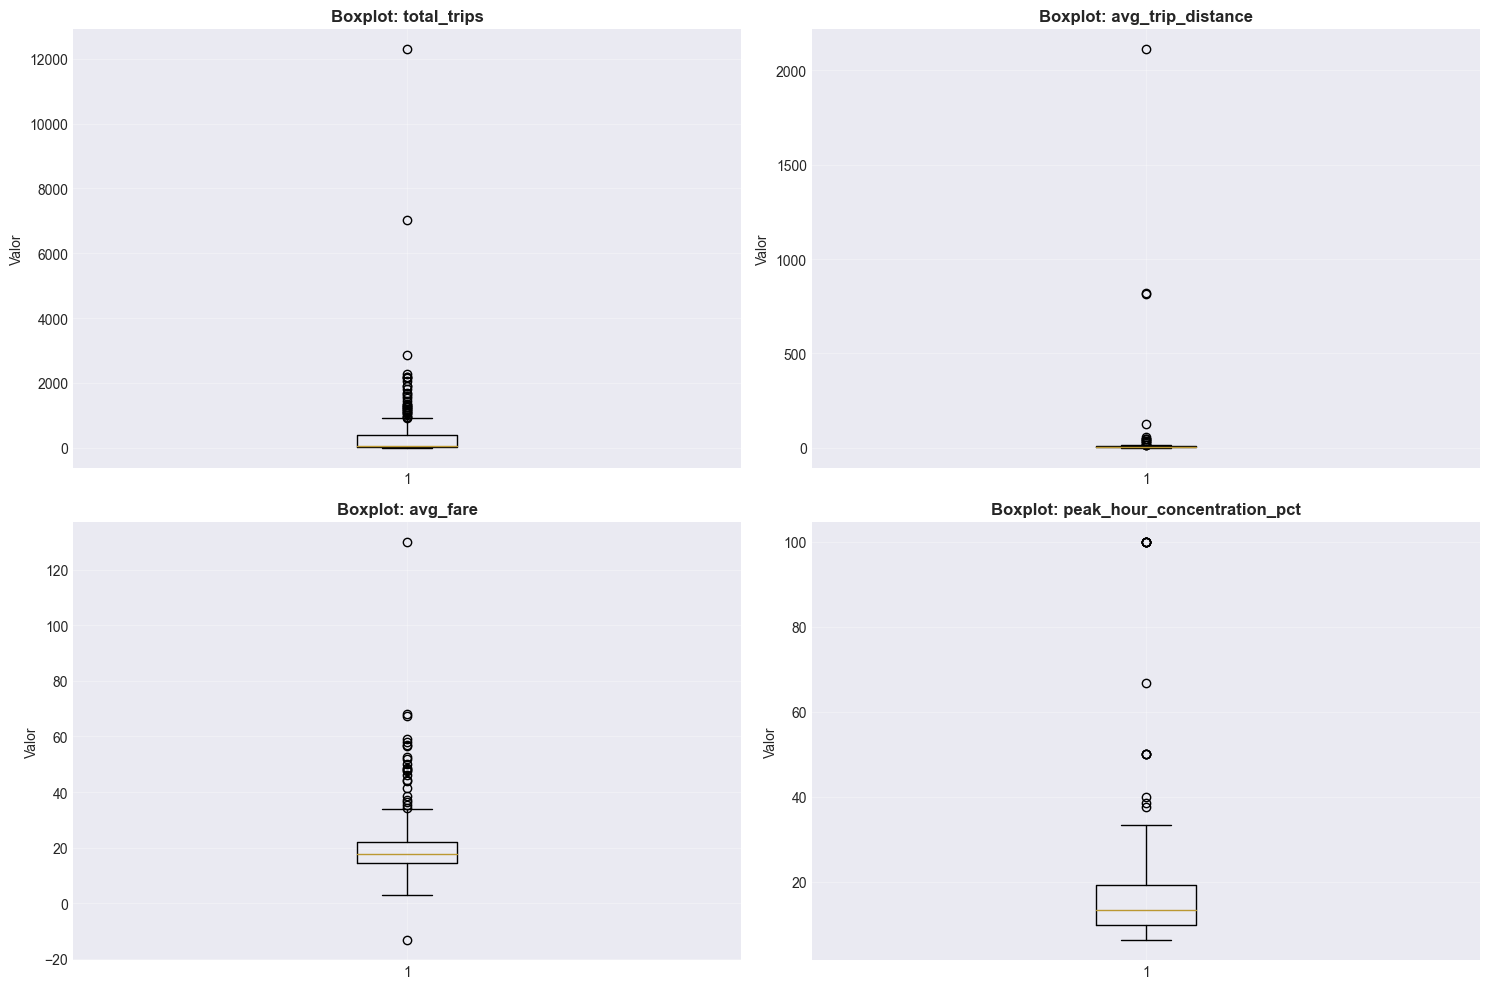

✓ Visualización completada


In [12]:
# Visualizar distribuciones y outliers de features clave
print("Visualizando distribuciones y outliers...")

# Features clave para analizar
key_features = [
    'total_trips',
    'avg_trip_distance',
    'avg_fare',
    'peak_hour_concentration_pct'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Boxplot
    axes[idx].boxplot(zone_features[feature].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot: {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualización completada")

## 5.2 Tratamiento de Outliers usando IQR

In [13]:
# Función para detectar outliers usando IQR
def detect_outliers_iqr(df, column, factor=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Detectar outliers en features clave
print("Detectando outliers...\n")

outlier_summary = []

for feature in key_features:
    outliers, lower, upper = detect_outliers_iqr(zone_features, feature)
    pct_outliers = (len(outliers) / len(zone_features)) * 100
    
    outlier_summary.append({
        'Feature': feature,
        'Outliers': len(outliers),
        'Porcentaje': f"{pct_outliers:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

# Para clustering, NO eliminaremos outliers, pero los capearemos (winsorization)
print("\n" + "="*60)
print("ESTRATEGIA: Aplicar Winsorization en lugar de eliminar outliers")
print("="*60)

Detectando outliers...

                       Feature  Outliers Porcentaje Lower Bound Upper Bound
0                  total_trips        33     13.36%     -517.75      920.25
1            avg_trip_distance        15      6.07%       -3.31       14.07
2                     avg_fare        24      9.72%        2.53       33.98
3  peak_hour_concentration_pct        15      6.07%       -4.62       33.68

ESTRATEGIA: Aplicar Winsorization en lugar de eliminar outliers


In [14]:
# Aplicar Winsorization (capear outliers en percentiles 1 y 99)
from scipy.stats.mstats import winsorize

print("Aplicando Winsorization...")

# Crear copia del dataframe
zone_features_clean = zone_features.copy()

# Aplicar winsorization a features numéricas (excepto zone_id)
numeric_features = zone_features_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('zone_id')  # No aplicar a ID

for feature in numeric_features:
    if zone_features_clean[feature].notna().sum() > 0:  # Solo si hay datos
        zone_features_clean[feature] = winsorize(
            zone_features_clean[feature].fillna(zone_features_clean[feature].median()),
            limits=[0.01, 0.01]  # Capear en percentiles 1 y 99
        )

print("✓ Winsorization aplicada")
print(f"\nShape después de tratamiento: {zone_features_clean.shape}")

Aplicando Winsorization...
✓ Winsorization aplicada

Shape después de tratamiento: (247, 25)


# 6. Imputación de Valores Nulos

In [15]:
# Verificar valores nulos después de agregación
print("Verificando valores nulos...\n")

missing_after = zone_features_clean.isnull().sum()
missing_pct_after = (missing_after / len(zone_features_clean)) * 100

missing_summary = pd.DataFrame({
    'Columna': missing_after.index,
    'Valores Nulos': missing_after.values,
    'Porcentaje': missing_pct_after.values
})
missing_summary = missing_summary[missing_summary['Valores Nulos'] > 0]

if len(missing_summary) > 0:
    print("Valores nulos encontrados:")
    print(missing_summary)
    
    # Imputar con mediana para features numéricas
    print("\nImputando valores nulos con mediana...")
    
    imputer = SimpleImputer(strategy='median')
    numeric_cols_to_impute = missing_summary['Columna'].tolist()
    
    zone_features_clean[numeric_cols_to_impute] = imputer.fit_transform(
        zone_features_clean[numeric_cols_to_impute]
    )
    
    print("✓ Imputación completada")
else:
    print("✓ No hay valores nulos para imputar")

# Verificación final
print(f"\nValores nulos restantes: {zone_features_clean.isnull().sum().sum()}")

Verificando valores nulos...

✓ No hay valores nulos para imputar

Valores nulos restantes: 0


# 7. Selección de Features para Clustering

Seleccionamos las features más relevantes para el clustering de zonas:

In [16]:
# Features seleccionadas para clustering
clustering_features = [
    # Volumen
    'total_trips',
    
    # Patrones temporales
    'avg_pickup_hour',
    'std_pickup_hour',
    'peak_hour',
    'peak_hour_concentration_pct',
    
    # Distribución por bandas horarias
    'pct_AM_Peak',
    'pct_PM_Peak',
    'pct_OP_day',
    'pct_OP_night',
    'pct_Early_Morning',
    
    # Patrones semanales
    'pct_weekend_trips',
    
    # Características del viaje
    'avg_trip_distance',
    'median_trip_distance',
    'avg_trip_duration',  # Corrected from 'avg_trip_time'
    
    # Características financieras
    'avg_fare',
    'avg_total_amount',
    'avg_tip',
    'avg_tolls',  # Using available feature instead of 'avg_driver_pay'
    
    # Tipo de servicio (Yellow vs Green taxi)
    'pct_yellow_taxi'  # Corrected from 'pct_uber'
]

# Crear dataset para clustering
X_clustering = zone_features_clean[clustering_features].copy()

print("=" * 60)
print("FEATURES SELECCIONADAS PARA CLUSTERING")
print("=" * 60)
print(f"\nTotal de features: {len(clustering_features)}")
print(f"\nFeatures:")
for i, feat in enumerate(clustering_features, 1):
    print(f"{i:2d}. {feat}")

print(f"\nShape del dataset de clustering: {X_clustering.shape}")

FEATURES SELECCIONADAS PARA CLUSTERING

Total de features: 19

Features:
 1. total_trips
 2. avg_pickup_hour
 3. std_pickup_hour
 4. peak_hour
 5. peak_hour_concentration_pct
 6. pct_AM_Peak
 7. pct_PM_Peak
 8. pct_OP_day
 9. pct_OP_night
10. pct_Early_Morning
11. pct_weekend_trips
12. avg_trip_distance
13. median_trip_distance
14. avg_trip_duration
15. avg_fare
16. avg_total_amount
17. avg_tip
18. avg_tolls
19. pct_yellow_taxi

Shape del dataset de clustering: (247, 19)


# 8. Normalización de Features

Para algoritmos de clustering basados en distancia (K-Means, DBSCAN), es crucial normalizar las features:

In [17]:
print("=" * 60)
print("NORMALIZACIÓN DE FEATURES")
print("=" * 60)

# Usar StandardScaler (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# Convertir a DataFrame para mantener nombres de columnas
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X_clustering.index
)

print("\n✓ Normalización completada con StandardScaler")
print(f"\nShape: {X_scaled_df.shape}")
print(f"\nEstadísticas después de normalización:")
print(X_scaled_df.describe().T[['mean', 'std', 'min', 'max']])

NORMALIZACIÓN DE FEATURES

✓ Normalización completada con StandardScaler

Shape: (247, 19)

Estadísticas después de normalización:
                              mean   std    min   max
total_trips                 -0.000 1.002 -0.590 4.445
avg_pickup_hour              0.000 1.002 -3.058 2.512
std_pickup_hour             -0.000 1.002 -2.705 2.765
peak_hour                    0.000 1.002 -2.037 1.843
peak_hour_concentration_pct -0.000 1.002 -0.666 4.979
pct_AM_Peak                  0.000 1.002 -1.300 3.721
pct_PM_Peak                 -0.000 1.002 -1.713 2.811
pct_OP_day                   0.000 1.002 -2.029 3.848
pct_OP_night                 0.000 1.002 -1.300 3.356
pct_Early_Morning            0.000 1.002 -0.893 4.734
pct_weekend_trips           -0.000 1.002 -1.826 3.874
avg_trip_distance            0.000 1.002 -0.169 8.956
median_trip_distance         0.000 1.002 -1.415 3.630
avg_trip_duration           -0.000 1.002 -1.615 4.975
avg_fare                    -0.000 1.002 -1.574 4.188
avg_t

# 9. Análisis de Correlación

Calculando matriz de correlación...


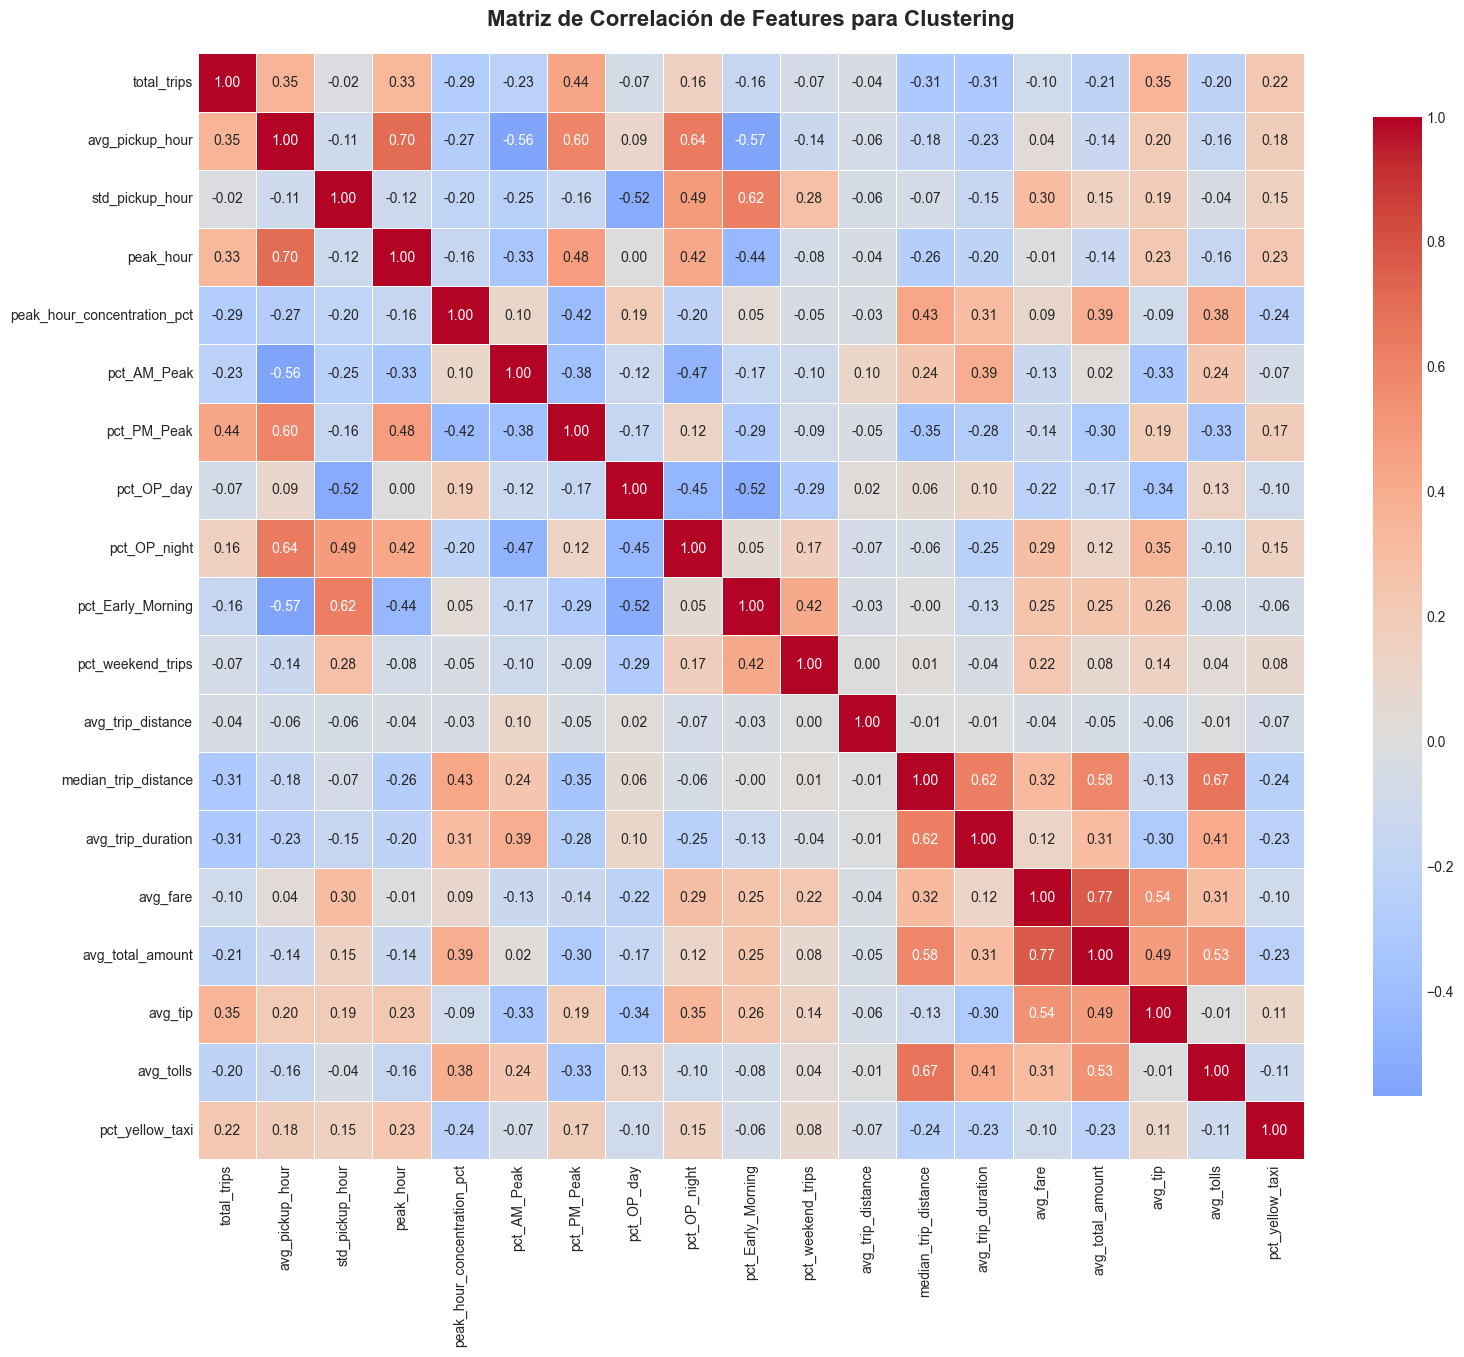

✓ Matriz de correlación generada


In [18]:
# Matriz de correlación
print("Calculando matriz de correlación...")

correlation_matrix = X_clustering.corr()

# Visualizar matriz de correlación
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación de Features para Clustering', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Matriz de correlación generada")

# 10. Reducción de Dimensionalidad (PCA)

Aplicamos PCA para visualización y análisis exploratorio:

ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

Varianza explicada por componente:
PC1: 23.66% (Acumulada: 23.66%)
PC2: 18.02% (Acumulada: 41.69%)
PC3: 12.87% (Acumulada: 54.55%)
PC4: 6.27% (Acumulada: 60.83%)
PC5: 6.06% (Acumulada: 66.89%)
PC6: 5.39% (Acumulada: 72.27%)
PC7: 4.78% (Acumulada: 77.05%)
PC8: 4.29% (Acumulada: 81.35%)
PC9: 3.68% (Acumulada: 85.02%)
PC10: 3.49% (Acumulada: 88.52%)


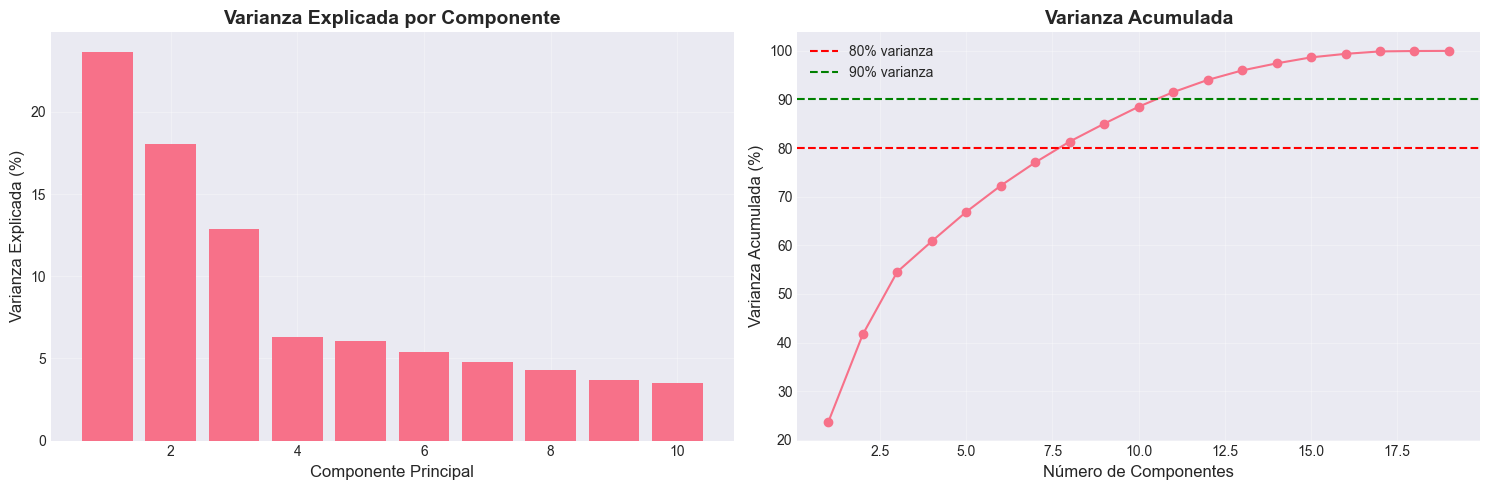


✓ Componentes necesarios para 90% varianza: 11


In [19]:
print("=" * 60)
print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 60)

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nVarianza explicada por componente:")
for i, (var, cum_var) in enumerate(zip(explained_variance[:10], cumulative_variance[:10]), 1):
    print(f"PC{i}: {var*100:.2f}% (Acumulada: {cum_var*100:.2f}%)")

# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Varianza por componente
axes[0].bar(range(1, len(explained_variance[:10])+1), explained_variance[:10]*100)
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, marker='o')
axes[1].axhline(y=80, color='r', linestyle='--', label='80% varianza')
axes[1].axhline(y=90, color='g', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=12)
axes[1].set_title('Varianza Acumulada', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Número de componentes para 90% de varianza
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\n✓ Componentes necesarios para 90% varianza: {n_components_90}")

# 11. Guardar Datos Preparados

In [20]:
import os
import joblib
import pandas as pd

# Define the directory for saving prepared data
output_dir = 'data_prep'
os.makedirs(output_dir, exist_ok=True)

print("=" * 60)
print("GUARDANDO DATASETS PREPARADOS")
print("=" * 60)

# 1. Dataset completo de features por zona (sin normalizar)
zone_features_clean.to_parquet(os.path.join(output_dir, 'zone_features_raw.parquet'), index=False)
print(f"✓ Guardado: {os.path.join(output_dir, 'zone_features_raw.parquet')}")

# 2. Dataset de features seleccionadas (sin normalizar)
# Agregar zone_id para referencia
X_clustering_with_id = X_clustering.copy()
X_clustering_with_id.insert(0, 'zone_id', zone_features_clean['zone_id'])
X_clustering_with_id.to_parquet(os.path.join(output_dir, 'zone_features_clustering.parquet'), index=False)
print(f"✓ Guardado: {os.path.join(output_dir, 'zone_features_clustering.parquet')}")

# 3. Dataset normalizado para clustering
X_scaled_with_id = X_scaled_df.copy()
X_scaled_with_id.insert(0, 'zone_id', zone_features_clean['zone_id'])
X_scaled_with_id.to_parquet(os.path.join(output_dir, 'zone_features_scaled.parquet'), index=False)
print(f"✓ Guardado: {os.path.join(output_dir, 'zone_features_scaled.parquet')}")

# 4. Guardar scaler para uso futuro
joblib.dump(scaler, os.path.join(output_dir, 'standard_scaler.pkl'))
print(f"✓ Guardado: {os.path.join(output_dir, 'standard_scaler.pkl')}")

# 5. Guardar PCA
joblib.dump(pca, os.path.join(output_dir, 'pca_model.pkl'))
print(f"✓ Guardado: {os.path.join(output_dir, 'pca_model.pkl')}")

# 6. Guardar componentes principales
pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
pca_df.insert(0, 'zone_id', zone_features_clean['zone_id'])
pca_df.to_parquet(os.path.join(output_dir, 'zone_features_pca.parquet'), index=False)
print(f"✓ Guardado: {os.path.join(output_dir, 'zone_features_pca.parquet')}")

print("\n" + "="*60)
print("PREPARACIÓN DE DATOS COMPLETADA")
print("="*60)
print(f"\nTotal de zonas procesadas: {len(zone_features_clean)}")
print(f"Total de features para clustering: {len(clustering_features)}")
print(f"\nArchivos generados en el directorio '{output_dir}':")
print("  1. zone_features_raw.parquet - Features sin normalizar")
print("  2. zone_features_clustering.parquet - Features seleccionadas")
print("  3. zone_features_scaled.parquet - Features normalizadas")
print("  4. zone_features_pca.parquet - Componentes principales")
print("  5. standard_scaler.pkl - Modelo de normalización")
print("  6. pca_model.pkl - Modelo PCA")

GUARDANDO DATASETS PREPARADOS
✓ Guardado: data_prep\zone_features_raw.parquet
✓ Guardado: data_prep\zone_features_clustering.parquet
✓ Guardado: data_prep\zone_features_scaled.parquet
✓ Guardado: data_prep\standard_scaler.pkl
✓ Guardado: data_prep\pca_model.pkl
✓ Guardado: data_prep\zone_features_pca.parquet

PREPARACIÓN DE DATOS COMPLETADA

Total de zonas procesadas: 247
Total de features para clustering: 19

Archivos generados en el directorio 'data_prep':
  1. zone_features_raw.parquet - Features sin normalizar
  2. zone_features_clustering.parquet - Features seleccionadas
  3. zone_features_scaled.parquet - Features normalizadas
  4. zone_features_pca.parquet - Componentes principales
  5. standard_scaler.pkl - Modelo de normalización
  6. pca_model.pkl - Modelo PCA


# 12. Resumen de la Preparación de Datos

## Features Creadas:

### 1. **Volumen de Demanda:**
- `total_trips`: Total de viajes por zona

### 2. **Patrones Temporales:**
- `avg_pickup_hour`: Hora promedio de pickup
- `std_pickup_hour`: Variabilidad de hora de pickup
- `peak_hour`: Hora con mayor demanda
- `peak_hour_concentration_pct`: % de viajes en hora pico

### 3. **Distribución por Bandas Horarias:**
- `pct_AM_Peak`: % viajes en pico mañana (6-10 AM)
- `pct_PM_Peak`: % viajes en pico tarde (4-8 PM)
- `pct_OP_day`: % viajes fuera de pico día (10 AM-4 PM)
- `pct_OP_night`: % viajes fuera de pico noche (8 PM-12 AM)
- `pct_Early_Morning`: % viajes madrugada (12-6 AM)

### 4. **Patrones Semanales:**
- `pct_weekend_trips`: % de viajes en fin de semana

### 5. **Características del Viaje:**
- `avg_trip_distance`: Distancia promedio
- `median_trip_distance`: Distancia mediana
- `avg_passengers`: Pasajeros promedio

### 6. **Características Financieras:**
- `avg_fare`: Tarifa promedio
- `avg_total_amount`: Monto total promedio
- `avg_tip`: Propina promedio

### 7. **Tipo de Servicio:**
- `pct_yellow_taxi`: % de taxis amarillos vs verdes

## Próximos Pasos:

1. **Fase 4: Modeling** - Aplicar algoritmos de clustering:
   - K-Means
   - DBSCAN
   - Hierarchical Clustering
   
2. **Fase 5: Evaluation** - Evaluar calidad de clusters:
   - Silhouette Score
   - Davies-Bouldin Index
   - Elbow Method
   
3. **Fase 6: Deployment** - Crear visualizaciones y recomendaciones